In [1]:
import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, glob as gb
from sklearn.metrics import confusion_matrix, classification_report
import itertools


2025-04-21 04:46:31.326555: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745210791.507774      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745210791.566763      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
# Parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
directory = "/kaggle/input/wheat-leaf-diseases/Wheat Leaf Diseases Dataset From Bangladesh"

# Dataset loading
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    directory,
    validation_split=0.1,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    directory,
    validation_split=0.1,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

class_names = train_dataset.class_names
num_classes = len(class_names)

# Class weight calculation
data_imbalance = [len(gb.glob(os.path.join(directory, class_folder, '*.*'))) for class_folder in class_names]
total_images = sum(data_imbalance)
class_weight = {
    i: (1.0 / count) * (total_images / len(data_imbalance))
    for i, count in enumerate(data_imbalance)
}


Found 3781 files belonging to 3 classes.
Using 3403 files for training.


I0000 00:00:1745210808.355486      31 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 3781 files belonging to 3 classes.
Using 378 files for validation.


In [3]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
])


In [4]:
# Model config
model_name = "deit_tiny_patch16_224"
input_resolution = 224

# Normalization
norm_layer = tf.keras.layers.Normalization(
    mean=[0.485 * 255, 0.456 * 255, 0.406 * 255],
    variance=[(0.229 * 255) ** 2, (0.224 * 255) ** 2, (0.225 * 255) ** 2],
)

import tensorflow as tf
import tensorflow_hub as hub

def build_deit_model():
    model_url = "https://tfhub.dev/sayakpaul/vit_b16_fe/1"  # feature extractor
    input_shape = (224, 224, 3)
    num_classes = len(class_names)  # replace with actual number of classes

    inputs = tf.keras.Input(shape=input_shape)

    # Wrap the hub.KerasLayer call inside a Lambda to avoid KerasTensor issues
    hub_module = hub.KerasLayer(model_url, trainable=True)

    def hub_forward(x):
        return hub_module(x)

    features = tf.keras.layers.Lambda(hub_forward)(inputs)
    x = tf.keras.layers.Dropout(0.3)(features)
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    return model





In [5]:
model = build_deit_model()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


model.summary()

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20,
    class_weight=class_weight
)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lambda (Lambda)                      │ (None, 768)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 768)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 3)                   │           2,307 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,307 (9.01 KB)

 Trainable params: 2,307 (9.01 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20


I0000 00:00:1745210859.227364      95 service.cc:148] XLA service 0x7a3c34006040 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1745210859.228177      95 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1745210860.516417      95 cuda_dnn.cc:529] Loaded cuDNN version 90300


  1/107 ━━━━━━━━━━━━━━━━━━━━ 22:33 13s/step - accuracy: 0.3750 - loss: 2.8862

I0000 00:00:1745210863.338969      95 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


107/107 ━━━━━━━━━━━━━━━━━━━━ 41s 265ms/step - accuracy: 0.4514 - loss: 1.7235 - val_accuracy: 0.7354 - val_loss: 0.6777
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 21s 194ms/step - accuracy: 0.5807 - loss: 1.0763 - val_accuracy: 0.7857 - val_loss: 0.5505
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 21s 195ms/step - accuracy: 0.6561 - loss: 0.8830 - val_accuracy: 0.8016 - val_loss: 0.4849
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 21s 193ms/step - accuracy: 0.7088 - loss: 0.7595 - val_accuracy: 0.8280 - val_loss: 0.4370
Epoch 5/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 21s 194ms/step - accuracy: 0.7222 - loss: 0.7161 - val_accuracy: 0.8466 - val_loss: 0.4007
Epoch 6/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 21s 196ms/step - accuracy: 0.7512 - loss: 0.6609 - val_accuracy: 0.8730 - val_loss: 0.3694
Epoch 7/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 21s 192ms/step - accuracy: 0.7729 - loss: 0.5990 - val_accuracy: 0.8810 - val_loss: 0.3384
Epoch 8/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 21s 195ms/step - accuracy: 0.7813 - loss: 0.5502 - val

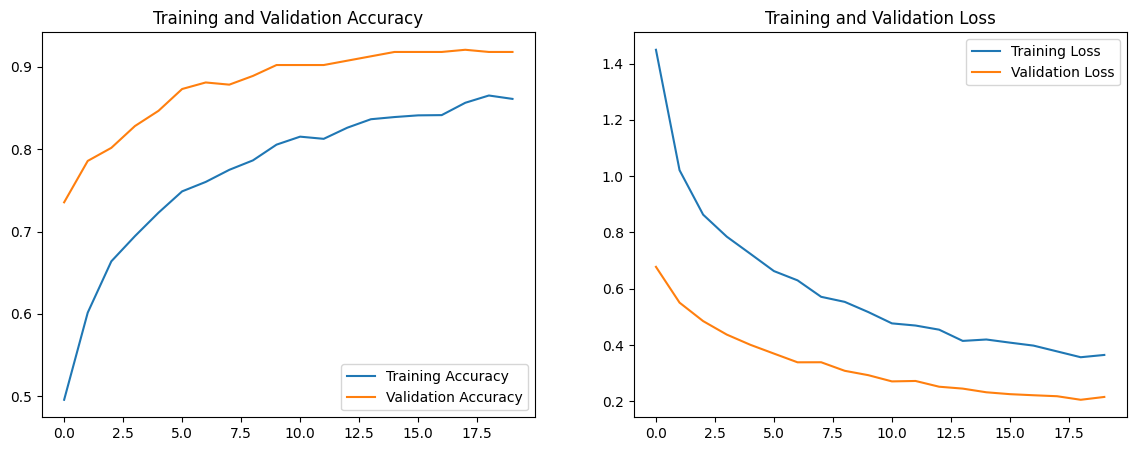

In [6]:
def plot_training(history):
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label="Training Accuracy")
    plt.plot(epochs_range, val_acc, label="Validation Accuracy")
    plt.legend(loc="lower right")
    plt.title("Training and Validation Accuracy")

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label="Training Loss")
    plt.plot(epochs_range, val_loss, label="Validation Loss")
    plt.legend(loc="upper right")
    plt.title("Training and Validation Loss")
    plt.show()

plot_training(history)


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


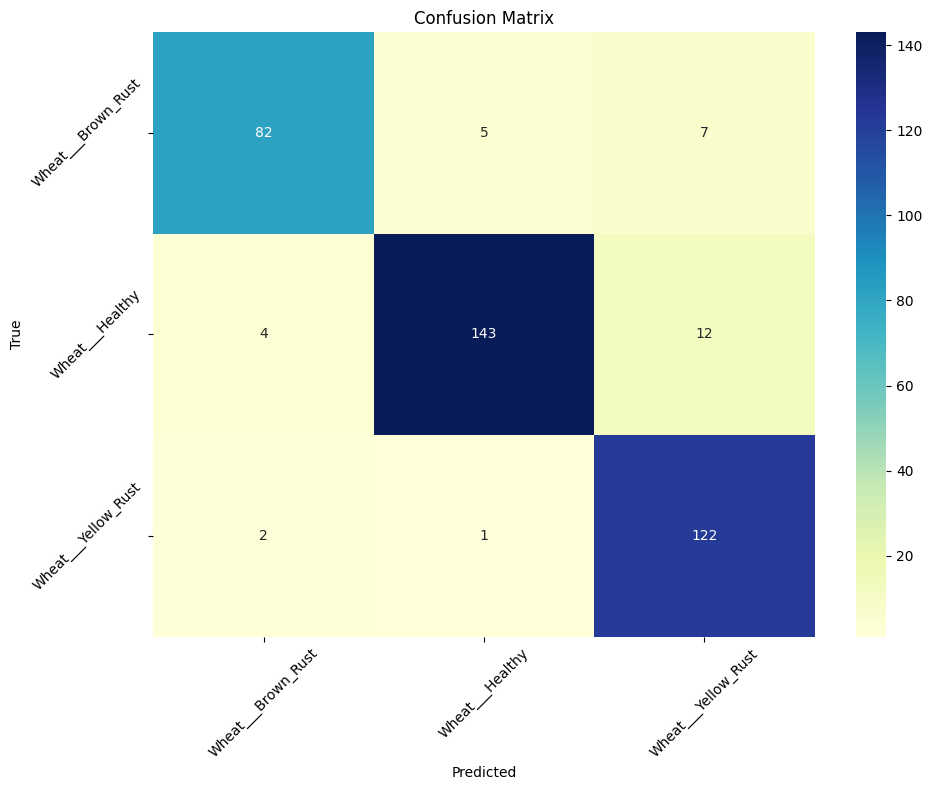


Classification Report:

                     precision    recall  f1-score   support

 Wheat___Brown_Rust       0.93      0.87      0.90        94
    Wheat___Healthy       0.96      0.90      0.93       159
Wheat___Yellow_Rust       0.87      0.98      0.92       125

           accuracy                           0.92       378
          macro avg       0.92      0.92      0.92       378
       weighted avg       0.92      0.92      0.92       378



In [7]:
# Get predictions
y_true = []
y_pred = []

for images, labels in val_dataset:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="YlGnBu")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()

# Classification report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))
